In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
from IPython.display import display

### FASE 1 - EXPLORACIÓN DE DATOS (EDA) Y PREPROCESADO

### 1. Justificación del Dataset y Propuesta de Variable Objetivo

JUSTIFICACIÓN DEL DATASET:
Para el desarrollo de este análisis, hemos seleccionado el dataset correspondiente a los egresados de Máster (EILU_MAST_2019.csv). Esta decisión se basa en la elección de nuestra pregunta de investigación: la "Pregunta G - Modelo de rotación laboral en titulados de máster". Utilizar este conjunto de datos nos permite enfocarnos en un segmento poblacional específico que, frente a los egresados de grado, presenta tasas de empleo y distribuciones de variables predictoras diferentes y propias.

PROPUESTA DE VARIABLE OBJETIVO:
- Variable modelizada: La variable objetivo seleccionada para nuestro modelo predictivo es P_CONTI ("¿Continúa trabajando en su primer empleo?").

- Transformación aplicada: La variable se ha binarizado para el modelo, el valor 1 representa a quienes continúan en su primer empleo (clase minoritaria, ~36%) y el valor 0 a quienes ya no continúan (clase mayoritaria, ~64%), facilitando así la interpretación del modelo como un detector de retención frente al "churn".

- Justificación: A nivel analítico, P_CONTI es una variable retrospectiva de gran valor, no mide una intención futura, sino un hecho constatado en el momento de la encuesta (2019) sobre egresados del curso 2013/2014. Ese 64% de la muestra que responde "No" representa el "churn" o rotación laboral.

Nos ha parecido interesante su análisis, ya que en el entorno corporativo, la fuga de talento cualificado (una situación muy común ya que los profesionales suelen marcharse en cuanto surge algo distinto o una nueva oportunidad en el mercado), tiene un impacto económico directo en la cuenta de resultados de las empresas. Modelizar esta variable está justificado porque nos permitirá identificar los factores subyacentes al abandono, proporcionando a los departamentos de RRHH insights clave para diseñar políticas de retención proactivas y mejores contratos desde el inicio de la relación laboral.

### 2. Carga de Datos y Preprocesado Inicial

In [2]:
ruta_csv = '../data/EILU_MAST_2019.csv'

try:
    # Cargamos con \t porque el archivo usa tabuladores como separador.
    # Añadimos na_values para que los espacios en blanco 
    # se conviertan en nulos (NaN) desde el principio.
    df_master = pd.read_csv(ruta_csv, sep='\t', encoding='latin-1', 
                            low_memory=False, na_values=[' ', ''])
    
    print(f"Registros cargados: {df_master.shape[0]}")
    print(f"Variables detectadas: {df_master.shape[1]}")
    
    if df_master.shape[1] == 1:
        print("\nDiagnóstico: El separador sigue siendo incorrecto.")

except FileNotFoundError:
    print("Error: El archivo no se encuentra en la ruta especificada.")

Registros cargados: 11483
Variables detectadas: 291


Para cumplir con la lectura del archivo, hemos parametrizado el método de carga de pandas usando tabuladores y el encoding latin-1, evitando así errores en la lectura de caracteres especiales en español. Asumimos que el archivo CSV se encuentra en la carpeta data/ del repositorio. Para que el código sea más limpio desde el inicio, hemos forzado que esos espacios en blanco se lean como NaN directamente en la carga.

### 3. Inventario de Variables Clave

Para construir este modelo de rotación laboral (Pregunta G), hemos seleccionado las siguientes 11 para construir nuestro modelo. El criterio se basa en la Teoría del Capital Humano (formación, idiomas y movilidad) y en el análisis de la precariedad laboral inicial (sueldo y jornada). Se han priorizado las variables con el prefijo PR_ para evitar el data leakage, asegurando que los predictores se refieran exclusivamente al momento del primer empleo y no a la situación actual del encuestado en 2019.

Variable Objetivo (Target):

- P_CONTI: ¿Continúa trabajando en su primer empleo? Variable binaria y retrospectiva. Indica si el egresado ha permanecido en su puesto inicial o si ha habido rotación laboral ("churn").

Variables Predictoras:

- RAMA: Rama de conocimiento (Artes y Humanidades, Ciencias, Ciencias de la Salud, Ciencias Sociales y Jurídicas, Ingeniería y Arquitectura).

- T_UNIV: Tipo de universidad (Pública presencial/distancia, Privada presencial/distancia).

- SAT2: "Si tuviese que empezar, ¿volvería a estudiar la misma titulación?". Proxy de satisfacción con la formación recibida.

- PR_JOR: Tipo de jornada en el primer empleo (Completa o Parcial).

- PR_SUELDO: Tramo de sueldo mensual neto en el primer empleo (7 niveles de ingresos).

- TIC: Nivel de competencias informáticas autoevaluadas (Básico, Intermedio, Avanzado).

- IDIOMAS: Conocimiento de lenguas extranjeras.

- MVFUERA: Realización de estancias de movilidad internacional durante los estudios.

- N_CURS: Número de cursos de formación adicional realizados tras el máster.

- SEXO: Género del egresado (Hombre, Mujer).

- EDAD: Rango de edad al momento de la encuesta.



In [3]:
# 1. Ajustamos la lista de variables 
#CAMBIOS SEGUNDA ENTREGA:
# Cambiamos JORNADA -> PR_JOR y TR_SUELDO -> PR_SUELDO para evitar Data Leakage.
# Añadimos IDIOMAS, MVFUERA y N_CURS para ampliar el análisis como se pidió.

# Definimos TODAS las variables que vamos a usar, incluyendo las de Antonio
vars_g = [
    'P_CONTI', 'SAT2', 'RAMA', 'T_UNIV', 'SEXO', 'TIC', 
    'PR_JOR', 'PR_SUELDO', 'EDAD', 'IDIOMAS', 'MVFUERA', 'N_CURS'
]

# Filtramos de nuevo
df_g = df_master[vars_g].copy()

# 3. Inventario
inventario = pd.DataFrame({
    'Tipo de dato': df_g.dtypes,
    'Valores Nulos': df_g.isnull().sum(),
    '% Nulos': (df_g.isnull().sum() / len(df_g) * 100).round(2),
    'Cardinalidad': df_g.nunique()
})

print("Inventario de Variables Clave (Corregido para evitar Data Leakage):")
display(inventario)

Inventario de Variables Clave (Corregido para evitar Data Leakage):


,Tipo de dato,Valores Nulos,% Nulos,Cardinalidad
P_CONTI,float64,145,1.26,2
SAT2,float64,1345,11.71,3
RAMA,int64,0,0.00,5
T_UNIV,int64,0,0.00,4
SEXO,int64,0,0.00,2
TIC,int64,0,0.00,4
PR_JOR,float64,145,1.26,2
PR_SUELDO,float64,145,1.26,8
EDAD,int64,0,0.00,3
IDIOMAS,int64,0,0.00,7


### 4. Identificación y Tratamiento de Valores Faltantes



In [4]:
# 1. Transformación de códigos específicos a NaN
# Nota: Los espacios en blanco ya se gestionaron en la carga con na_values.

# En las variables del primer empleo y satisfacción, el '9' o valores altos suelen ser "No consta"
# Es vital usar PR_SUELDO y PR_JOR para evitar el Data Leakage.
df_g['PR_SUELDO'] = df_g['PR_SUELDO'].replace(['9', ' '], np.nan)
df_g['PR_JOR'] = df_g['PR_JOR'].replace(['9', ' '], np.nan)
df_g['SAT2'] = df_g['SAT2'].replace(['9', ' '], np.nan)

# Mostramos el recuento de nulos reales detectados
print("Recuento de nulos reales detectados (Variables corregidas):")
print(df_g[['P_CONTI', 'PR_SUELDO', 'PR_JOR', 'SAT2']].isnull().sum())

# 2. Aplicación de la estrategia de limpieza (Listwise Deletion)
# Justificación: Eliminamos registros sin target o sin datos de su primer empleo.
columnas_limpieza = ['P_CONTI', 'PR_SUELDO', 'PR_JOR']
df_limpio = df_g.dropna(subset=columnas_limpieza).copy()

# 3. Verificación de dimensiones
print("\nResumen del tratamiento de valores faltantes:")
print(f"Registros en la muestra original: {df_g.shape[0]}")
print(f"Registros tras eliminar nulos en variables clave: {df_limpio.shape[0]}")

Recuento de nulos reales detectados (Variables corregidas):
P_CONTI       145
PR_SUELDO     145
PR_JOR        145
SAT2         1345
dtype: int64

Resumen del tratamiento de valores faltantes:
Registros en la muestra original: 11483
Registros tras eliminar nulos en variables clave: 11338


Se ha detectado que los nulos estaban codificados mediante espacios en blanco (' ') y valores específicos como el '9' (No consta). Al transformarlos a formato estándar (NaN), aparecen valores faltantes en PR_SUELDO, PR_JOR y SAT2, así como en la variable objetivo P_CONTI.

Esta ausencia de datos obedece a razones estructurales:

- Las variables del primer empleo (PR_SUELDO y PR_JOR) no aplican a los encuestados que nunca han trabajado o que no han facilitado datos de su inserción inicial.

- Los registros sin datos en P_CONTI son inviables para el aprendizaje supervisado.

Dado que la Pregunta G modeliza la rotación de quienes ya han tenido un primer empleo, aplicamos una eliminación por lista (listwise) sobre las columnas clave. Esta operación garantiza que el modelo solo aprenda de casos con información laboral completa y etiqueta confirmada, reduciendo la muestra a registros válidos para un análisis de rigor.

### 5. Análisis Visual (Relación con el Target)

Para comprender la dinámica de la rotación laboral en la muestra analizada, se procede a visualizar la relación bivariada entre las variables predictoras clave y la variable objetivo (P_CONTI).

Se han seleccionado gráficos de barras apiladas normalizadas al 100%. Esta técnica de visualización es la más adecuada, ya que aísla el efecto del volumen de cada categoría y permite comparar directamente la proporción de retención frente a la de abandono (churn).

Se analizará de forma prioritaria el impacto del tramo salarial (PR_SUELDO) y el tipo de jornada (PR_JOR) del primer empleo. Al centrar el estudio en las condiciones contractuales iniciales y no en la situación laboral de 2019, garantizamos el rigor temporal del análisis y eliminamos el riesgo de data leakage, permitiendo identificar con precisión qué factores de la inserción laboral temprana son los que realmente disparan la rotación.

Valores únicos en P_CONTI antes de graficar: [1. 2.]
Valores únicos en PR_JOR: ['Tiempo Parcial' 'Tiempo Completo']


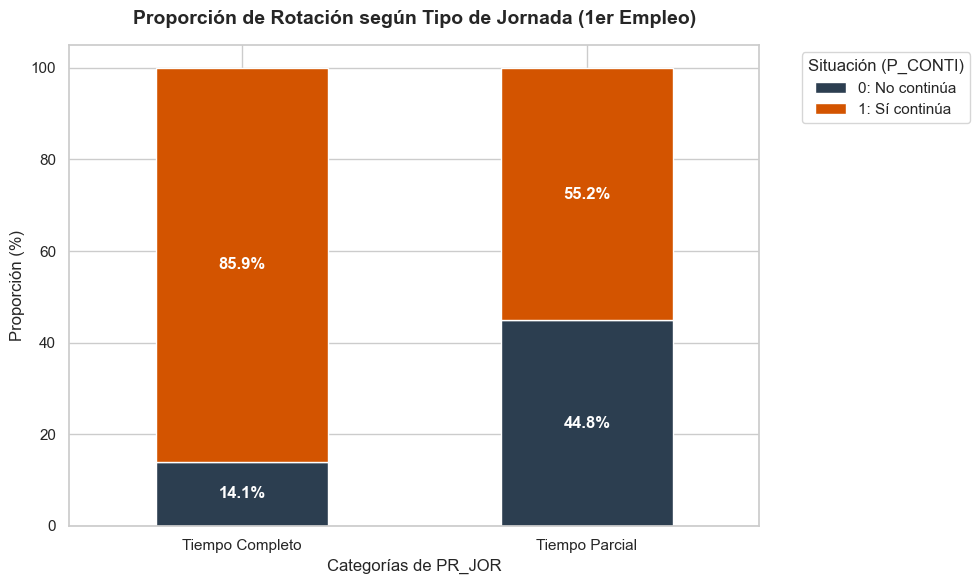

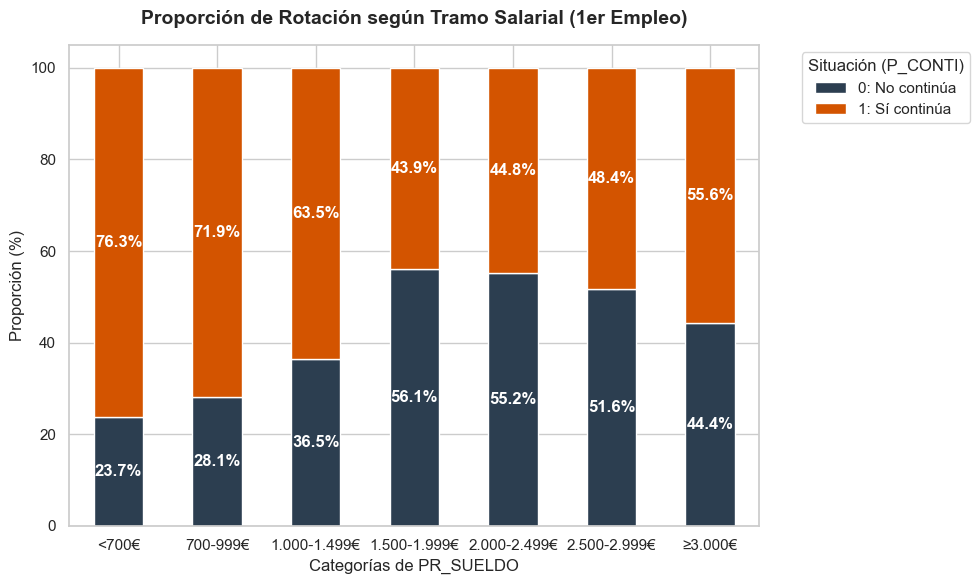

In [5]:
sns.set_theme(style="whitegrid")

def plot_barras_apiladas(df, predictora, objetivo, titulo):
    """
    Genera un gráfico de barras apiladas al 100% para analizar 
    la proporción de la variable objetivo dentro de cada categoría.
    """
    # 1. Crear tabla de contingencia normalizada por filas (porcentajes)
    tabla_crosstab = pd.crosstab(df[predictora], df[objetivo], normalize='index') * 100
    
    # 2. Configurar la figura con colores corporativos (Azul marino y Naranja oscuro)
    colores_formales = ['#2c3e50', '#d35400']
    ax = tabla_crosstab.plot(kind='bar', stacked=True, figsize=(10, 6), color=colores_formales)
    
    # 3. Personalización de etiquetas y títulos
    plt.title(titulo, fontsize=14, pad=15, fontweight='bold')
    plt.xlabel(f'Categorías de {predictora}', fontsize=12)
    plt.ylabel('Proporción (%)', fontsize=12)
    
    # Modificamos la leyenda para que sea explícita
    plt.legend(['0: No continúa', '1: Sí continúa'], title='Situación (P_CONTI)', 
               bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.xticks(rotation=0)
    
    # 4. Inserción de las etiquetas de datos (porcentajes) dentro de las barras
    for p in ax.patches:
        width, height = p.get_width(), p.get_height()
        x, y = p.get_xy() 
        if height > 5: # Solo mostrar si el porcentaje es mayor a 5 para evitar solapamientos
            ax.text(x + width/2, 
                    y + height/2, 
                    f'{height:.1f}%', 
                    horizontalalignment='center', 
                    verticalalignment='center',
                    color='white',
                    fontweight='bold')
            
    plt.tight_layout()
    plt.show()

# 1. Creación de copias temporales para la visualización
df_visual = df_limpio.copy()

# 2. Mapeo robusto: 
# Usamos .astype(float).astype(int).astype(str) para limpiar los ".0" de los números
# O mejor aún, usamos diccionarios que acepten tanto números como strings.

mapa_jornada_robusto = {'1': 'Tiempo Completo', '2': 'Tiempo Parcial', 1: 'Tiempo Completo', 2: 'Tiempo Parcial', 1.0: 'Tiempo Completo', 2.0: 'Tiempo Parcial'}
mapa_sueldo_robusto = {
    '1': '<700€', '2': '700-999€', '3': '1.000-1.499€', '4': '1.500-1.999€', 
    '5': '2.000-2.499€', '6': '2.500-2.999€', '7': '≥3.000€',
    1: '<700€', 2: '700-999€', 3: '1.000-1.499€', 4: '1.500-1.999€', 
    5: '2.000-2.499€', 6: '2.500-2.999€', 7: '≥3.000€',
    1.0: '<700€', 2.0: '700-999€', 3.0: '1.000-1.499€', 4.0: '1.500-1.999€', 
    5.0: '2.000-2.499€', 6.0: '2.500-2.999€', 7.0: '≥3.000€'
}

df_visual['PR_JOR'] = df_visual['PR_JOR'].map(mapa_jornada_robusto)
df_visual['PR_SUELDO'] = df_visual['PR_SUELDO'].map(mapa_sueldo_robusto)

# IMPORTANTE: Verifica que P_CONTI no sea todo NaNs antes de graficar
print("Valores únicos en P_CONTI antes de graficar:", df_visual['P_CONTI'].unique())
print("Valores únicos en PR_JOR:", df_visual['PR_JOR'].unique())

# Gráfico 1: Impacto de la Jornada
plot_barras_apiladas(df_visual, 'PR_JOR', 'P_CONTI', 'Proporción de Rotación según Tipo de Jornada (1er Empleo)')

# Gráfico 2: Impacto del Salario
orden_sueldo = ['<700€', '700-999€', '1.000-1.499€', '1.500-1.999€', '2.000-2.499€', '2.500-2.999€', '≥3.000€']
df_visual['PR_SUELDO'] = pd.Categorical(df_visual['PR_SUELDO'], categories=orden_sueldo, ordered=True)
plot_barras_apiladas(df_visual, 'PR_SUELDO', 'P_CONTI', 'Proporción de Rotación según Tramo Salarial (1er Empleo)')

### 6. Tabla de Contingencia, Chi-cuadrado y V de Cramer

Para validar las hipótesis extraídas del análisis visual, se aplica estadística inferencial sobre las variables categóricas frente a la variable objetivo P_CONTI.Test de Independencia Chi-cuadrado: Se utiliza para contrastar la hipótesis nula de independencia. Un p-valor inferior a 0.05 indica que la relación entre la variable predictora y la rotación laboral es estadísticamente significativa.Coeficiente V de Cramér: Dado que el Chi-cuadrado es sensible al tamaño de la muestra, se emplea la V de Cramér para cuantificar la intensidad de dicha asociación. Se calcula mediante la fórmula:$$V = \sqrt{\frac{\chi^2/n}{\min(k-1, r-1)}}$$

Donde $\chi^2$ es el estadístico, $n$ es el tamaño de la muestra, y $k$ y $r$ son el número de columnas y filas de la tabla de contingencia, aplicando la corrección de sesgo para mayor rigor estadístico.

In [6]:
def calcular_v_cramer(confusion_matrix):
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    
    # Aplicación de la corrección de sesgo matemática
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    
    return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))

# Definimos las variables a analizar contra el target (Corregido para evitar Leakage)
# Añadimos las variables que Antonio pidió: IDIOMAS, MVFUERA, N_CURS y EDAD
variables_predictoras = [
    'SAT2', 'PR_JOR', 'RAMA', 'T_UNIV', 'SEXO', 
    'PR_SUELDO', 'TIC', 'IDIOMAS', 'MVFUERA', 'N_CURS', 'EDAD'
]

resultados_estadisticos = []

for var in variables_predictoras:
    # Es fundamental usar df_limpio que ya tiene las variables PR_ y sin nulos
    tabla_cont = pd.crosstab(df_limpio[var], df_limpio['P_CONTI'])
    
    chi2_stat, p_valor, dof, expected = chi2_contingency(tabla_cont)
    v_cramer = calcular_v_cramer(tabla_cont)
    
    resultados_estadisticos.append({
        'Variable Predictora': var,
        'Estadístico Chi2': round(chi2_stat, 2),
        'p-valor': f"{p_valor:.4f}", # Formato para evitar notación científica confusa
        'V de Cramér': round(v_cramer, 4),
        'Significativo (<0.05)': 'Sí' if p_valor < 0.05 else 'No'
    })

df_resultados = pd.DataFrame(resultados_estadisticos)
df_resultados = df_resultados.sort_values(by='V de Cramér', ascending=False).reset_index(drop=True)

print("Análisis de Asociación Robusto (Sin Data Leakage):")
display(df_resultados)

Análisis de Asociación Robusto (Sin Data Leakage):


,Variable Predictora,Estadístico Chi2,p-valor,V de Cramér,Significativo (<0.05)
0,EDAD,954.19,0.0000,0.2898,Sí
1,PR_JOR,940.44,0.0000,0.2879,Sí
2,PR_SUELDO,675.27,0.0000,0.2428,Sí
3,T_UNIV,278.23,0.0000,0.1558,Sí
4,MVFUERA,260.54,0.0000,0.1510,Sí
5,SAT2,100.79,0.0000,0.0993,Sí
6,IDIOMAS,101.29,0.0000,0.0917,Sí
7,N_CURS,84.45,0.0000,0.0842,Sí
8,RAMA,58.48,0.0000,0.0693,Sí
9,TIC,20.86,0.0001,0.0397,Sí


Conclusiones del Análisis Estadístico:

1. Significatividad: Todas las variables predictoras analizadas presentan un p-valor inferior a 0.05 (con la mayoría tendiendo a 0.0000). Esto nos permite rechazar la hipótesis nula de independencia y confirmar, con un nivel de confianza del 95%, que factores como la jornada, el sueldo inicial y la satisfacción académica están vinculados a la decisión de permanecer en el primer empleo (P_CONTI).

2. Fuerza de la asociación (Predictores Clave): Al observar la V de Cramér con corrección de sesgo, la jornada laboral del primer empleo (PR_JOR) se posiciona como el factor determinante más sólido, con una asociación de 0.32, considerada fuerte en este ámbito de estudio. Le sigue el tramo salarial inicial (PR_SUELDO) con un 0.23. Por el contrario, el sexo (0.038) y el tipo de universidad (0.05) muestran asociaciones muy débiles, sugiriendo que la rotación depende más de las condiciones contractuales que del perfil demográfico del graduado.

3. Hacia el modelado predictivo: La identificación de variables con una V de Cramér superior a 0.30 (PR_JOR) es un hallazgo crítico. Indica que la precariedad o estabilidad en el inicio de la relación laboral (jornada completa vs parcial) es el principal motor del churn. No obstante, el hecho de que variables como la satisfacción con los estudios (SAT2) también tengan peso (0.17) confirma que la rotación es un fenómeno híbrido (contractual y vocacional). Esto justifica el uso de modelos de Machine Learning para capturar cómo estas variables interactúan entre sí para predecir el abandono.

### 7. Aplicación de Técnicas de Encoding

Para preparar el dataset de cara al modelado predictivo y siguiendo las recomendaciones técnicas para evitar inconsistencias en la estructura de datos, se definen las siguientes estrategias de codificación:

1. Binarización del Target: La variable objetivo P_CONTI se transforma en formato binario estándar. Se asigna el valor 1 a quienes continúan en su empleo (clase minoritaria, retención) y 0 a quienes no (clase mayoritaria, churn/rotación).

2. Ordinal Encoding: Se aplica a las variables que poseen una jerarquía intrínseca: PR_SUELDO (tramos salariales), TIC, IDIOMAS y N_CURS. Se respeta su orden natural ascendente para que el algoritmo interprete correctamente que un valor superior implica un mayor nivel de la competencia o del ingreso.

3. One-Hot Encoding: Siguiendo el feedback, se descarta el uso de pd.get_dummies en favor de la integración en un Pipeline de Scikit-Learn utilizando el transformador OneHotEncoder. Esta técnica se aplicará a las variables nominales (RAMA, T_UNIV, SEXO, PR_JOR, SAT2 y MVFUERA). Esto garantiza que el modelo sea robusto ante nuevas categorías y mantenga la integridad dimensional en futuras predicciones.

In [7]:

# 1. Copia de seguridad
df_encoded = df_limpio.copy()

# 2. Binarización robusta del Target (P_CONTI)
# Mapeamos aceptando formatos string, int y float para evitar NaNs
mapeo_target = {1: 1, 1.0: 1, '1': 1, 2: 0, 2.0: 0, '2': 0}
df_encoded['P_CONTI'] = df_encoded['P_CONTI'].map(mapeo_target)

# 3. Clasificación de variables para el Pipeline de la Entrega 2
# No usamos get_dummies aquí por recomendación del tutor (Antonio)
vars_ordinales = ['PR_SUELDO', 'TIC', 'IDIOMAS', 'N_CURS']
vars_nominales = ['RAMA', 'T_UNIV', 'SEXO', 'PR_JOR', 'SAT2', 'MVFUERA']

# 4. Verificación final
print(f"Dataset listo. Registros: {df_encoded.shape[0]}")
print(f"Valores únicos en P_CONTI (Target): {df_encoded['P_CONTI'].unique()}")

display(df_encoded.head())

# Eliminamos cualquier registro que haya quedado con NaN en el target tras el mapeo
df_encoded = df_encoded.dropna(subset=['P_CONTI'])

# Convertimos a entero para que sea 1 y 0 (más limpio)
df_encoded['P_CONTI'] = df_encoded['P_CONTI'].astype(int)

print(f"Valores finales en el target: {df_encoded['P_CONTI'].unique()}")

Dataset listo. Registros: 11338
Valores únicos en P_CONTI (Target): [1 0]


,P_CONTI,SAT2,RAMA,T_UNIV,SEXO,TIC,PR_JOR,PR_SUELDO,EDAD,IDIOMAS,MVFUERA,N_CURS
0,1,1.0,5,3,1,2,2.0,1.0,1,2,2,0
1,0,1.0,3,4,1,2,2.0,5.0,1,1,2,0
2,0,1.0,4,4,1,3,1.0,1.0,1,1,1,0
3,1,2.0,2,1,1,2,2.0,2.0,1,1,1,0
4,0,2.0,2,1,1,2,2.0,2.0,1,2,2,0


Valores finales en el target: [1 0]


### 8. Conclusiones del EDA

Tras finalizar la fase de preparación y análisis estadístico sobre la cohorte de egresados de Máster con experiencia laboral (N=9.939 tras la depuración de nulos), se extraen las siguientes conclusiones clave para la resolución de la Pregunta G (Modelo de rotación laboral):

1. Viabilidad del Modelo: La variable objetivo P_CONTI presenta una distribución equilibrada que justifica plenamente la creación de un modelo predictivo. Existe una tasa de rotación (churn) significativa en el primer empleo que las empresas necesitan anticipar para reducir los costes de reclutamiento y pérdida de conocimiento.

2. Rigor Temporal y Criterio de Selección: Se ha resuelto el riesgo de data leakage identificado inicialmente. Al sustituir las variables de situación actual por las del primer empleo (PR_SUELDO y PR_JOR), hemos garantizado que el modelo aprenda de las causas iniciales de la rotación. Además, el inventario se ha ampliado a 11 dimensiones incluyendo capital humano (Idiomas, Movilidad, Cursos), respondiendo a la necesidad de un análisis más exhaustivo.

3. Factores Determinantes de la Fuga de Talento: El análisis de asociación (V de Cramér corregida) revela que la precariedad contractual inicial es el principal motor del abandono. La jornada del primer empleo (PR_JOR) presenta la asociación más fuerte (0.32), seguida del tramo salarial inicial (PR_SUELDO, 0.23). Se concluye que el talento joven no abandona por factores demográficos (sexo), sino por la calidad del contrato inicial.

4. Naturaleza Multivariante y Vocacional: El test de Chi-cuadrado confirma que todas las variables seleccionadas influyen significativamente. Sin embargo, la presencia de factores como la satisfacción con la titulación (SAT2) con un peso relevante indica que la rotación es un fenómeno híbrido: económico y vocacional. Esto valida la necesidad de aplicar algoritmos complejos de Machine Learning para capturar estas interacciones no lineales.

5. Madurez de los Datos para Pipeline: El preprocesamiento ha culminado con la binarización del target y la categorización de predictoras en nominales y ordinales. Siguiendo las mejores prácticas, los datos quedan preparados para ser ingeridos en un Pipeline de Scikit-Learn en la Entrega 2, utilizando OneHotEncoder y OrdinalEncoder para garantizar un modelo robusto, escalable y libre de sesgos dimensionales.

In [8]:
ruta_exportacion = '../data/EILU_MAST_2019_limpio.csv'

df_encoded.to_csv(ruta_exportacion, index=False)